<a href="https://colab.research.google.com/github/mrunalkavade/Deep-Learning-Based-COVID-19-Classification-Using-Chest-Radiography-Images/blob/main/Copy_of_resnet_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🔹 1. Google Drive Integration & Dataset Extraction

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = "/content/drive/MyDrive/DL/archive.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted Successfully")

Mounted at /content/drive
Extracted Successfully


🔹 2. Dataset Path Setup

In [ ]:
dataset_path = "/content/dataset/COVID-19_Radiography_Dataset"

🔹 3. Data Splitting (Train, Validation, Test)

In [ ]:
import shutil
import random
import os

dataset_path = "/content/dataset/COVID-19_Radiography_Dataset"

if os.path.exists("/content/data_split"):
    shutil.rmtree("/content/data_split")

base_dir = "/content/data_split"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

os.makedirs(train_dir)
os.makedirs(val_dir)
os.makedirs(test_dir)

classes = [cls for cls in os.listdir(dataset_path)
           if os.path.isdir(os.path.join(dataset_path, cls))]

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    image_folder = os.path.join(cls_path, "images")

    images = [img for img in os.listdir(image_folder)
              if img.endswith(('.png', '.jpg', '.jpeg'))]

    random.shuffle(images)

    train_split = int(0.7 * len(images))
    val_split = int(0.85 * len(images))

    splits = {
        train_dir: images[:train_split],
        val_dir: images[train_split:val_split],
        test_dir: images[val_split:]
    }

    for folder, split_imgs in splits.items():
        os.makedirs(os.path.join(folder, cls), exist_ok=True)

        for img in split_imgs:
            shutil.copy(os.path.join(image_folder, img),
                        os.path.join(folder, cls, img))

print("Data Split Done")

Data Split Done


🔹 4. Data Preprocessing & Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

🔹 5. Data Generators Creation

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 14814 images belonging to 4 classes.
Found 3175 images belonging to 4 classes.
Found 3176 images belonging to 4 classes.


🔹 6. Model Building using ResNet50

🔹 7. Custom Classification Head

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


🔹 8. Model Compilation

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

🔹 9. Model Training with Early Stopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 287s 582ms/step - accuracy: 0.7290 - loss: 0.7832 - val_accuracy: 0.8542 - val_loss: 0.4278
Epoch 2/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 244s 526ms/step - accuracy: 0.8120 - loss: 0.5281 - val_accuracy: 0.8706 - val_loss: 0.3664
Epoch 3/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 242s 523ms/step - accuracy: 0.8385 - loss: 0.4554 - val_accuracy: 0.8772 - val_loss: 0.3493
Epoch 4/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 242s 523ms/step - accuracy: 0.8503 - loss: 0.4206 - val_accuracy: 0.8838 - val_loss: 0.3288
Epoch 5/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 233s 503ms/step - accuracy: 0.8557 - loss: 0.3962 - val_accuracy: 0.8894 - val_loss: 0.3128
Epoch 6/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 236s 510ms/step - accuracy: 0.8638 - loss: 0.3656 - val_accuracy: 0.8879 - val_loss: 0.3025
Epoch 7/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 228s 492ms/step - accuracy: 0.8732 - loss: 0.3477 - val_accuracy: 0.8894 - val_loss: 0.3097
Epoch 8/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 230s 497ms/step - accuracy: 0.8748 -

🔹 10. Model Evaluation (Before Fine-Tuning)

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)

100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 153ms/step - accuracy: 0.9030 - loss: 0.2601
Test Accuracy: 0.9030226469039917


🔹 11. Fine-Tuning the Model

🔹 12. Retraining After Fine-Tuning

In [ ]:
# Unfreeze last layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 266s 528ms/step - accuracy: 0.8687 - loss: 0.3643 - val_accuracy: 0.8986 - val_loss: 0.2863
Epoch 2/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 224s 484ms/step - accuracy: 0.8831 - loss: 0.3257 - val_accuracy: 0.9052 - val_loss: 0.2589
Epoch 3/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 224s 483ms/step - accuracy: 0.8968 - loss: 0.2900 - val_accuracy: 0.9216 - val_loss: 0.2454
Epoch 4/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 226s 489ms/step - accuracy: 0.9012 - loss: 0.2735 - val_accuracy: 0.9200 - val_loss: 0.2377
Epoch 5/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 224s 484ms/step - accuracy: 0.9096 - loss: 0.2537 - val_accuracy: 0.9175 - val_loss: 0.2417
Epoch 6/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 228s 493ms/step - accuracy: 0.9171 - loss: 0.2318 - val_accuracy: 0.9231 - val_loss: 0.2309
Epoch 7/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 226s 488ms/step - accuracy: 0.9201 - loss: 0.2175 - val_accuracy: 0.9200 - val_loss: 0.2284
Epoch 8/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 240s 518ms/step - accuracy: 0.9226 -

🔹 13. Final Model Evaluation

🔹 14. Predictions & Accuracy Calculation

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy after fine-tuning:", test_accuracy)

100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 141ms/step - accuracy: 0.9336 - loss: 0.1853
Test Accuracy after fine-tuning: 0.9335642457008362


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes

print("Test Accuracy:", accuracy_score(y_true, y_pred_classes))

100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 190ms/step
Test Accuracy: 0.9335642317380353


🔹 15. Accuracy & Loss Visualization

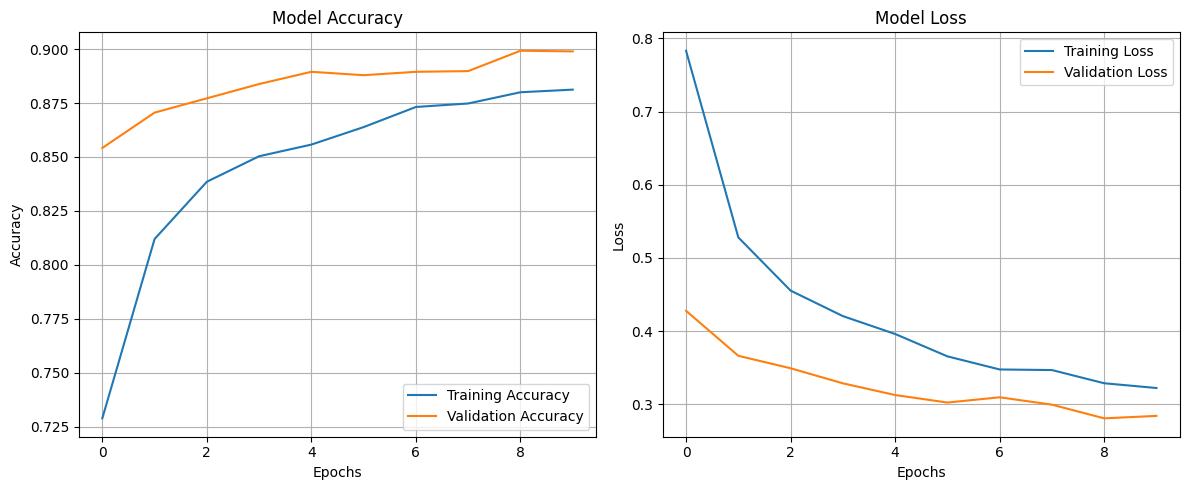

In [ ]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(12, 5))

# -------- Accuracy Plot --------
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# -------- Loss Plot --------
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

# Show both plots
plt.tight_layout()
plt.show()

🔹 16. Classification Report

In [ ]:
print(classification_report(y_true, y_pred_classes, target_names=classes))

                 precision    recall  f1-score   support

          COVID       0.98      0.92      0.94       543
   Lung_Opacity       0.91      0.91      0.91       902
         Normal       0.93      0.95      0.94      1529
Viral Pneumonia       0.96      0.96      0.96       202

       accuracy                           0.93      3176
      macro avg       0.95      0.93      0.94      3176
   weighted avg       0.93      0.93      0.93      3176



🔹 17. Confusion Matrix Visualization

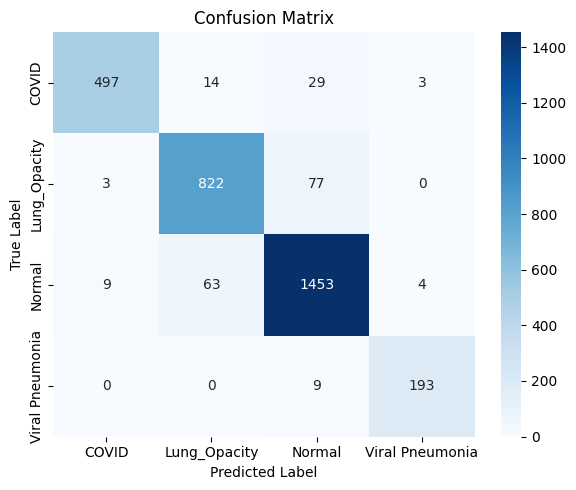

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Get class labels
classes = list(test_generator.class_indices.keys())

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',   # 🔵 Blue professional theme
            xticklabels=classes,
            yticklabels=classes)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()